In [14]:
import math
class Value:
    def __init__(self,data,_children=(),_op="",label=""):
        self.data=data
        self.grad=0.0
        self._backward=lambda:None
        self._prev=set(_children)
        self._op=_op
        self.label=label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),"+")
        def _backward():
            self.grad += 1.0* out.grad
            other.grad += 1.0* out.grad
        out._backward= _backward
        return out
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),"*")
        def _backward():
            self.grad +=other.data*out.grad
            other.grad += self.data*out.grad
        out._backward= _backward
        return out
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward
        return out

    def __rmul__(self,other):
        return self*other

    def __truediv__(self,other):
        return self*other**-1
    def __neg__(self): #-self
        return self * -1
    def __sub__(self, other): # self - other
        return self + (-other)

    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out= Value(t,(self,),"tanh")
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward= _backward
        return out
    def exp(self): #x.exp()= e^x
        x=self.data
        out=Value(math.exp(x),(self,),"exp")
        def _backward():
            self.grad=out.data*out.grad
        out._backward= _backward
        return out
        
    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

In [17]:
a= Value(2.0)
b=Value(4.0)
a.exp()

Value(data=7.38905609893065)

In [11]:
a=Value(2.0,label="a")
b=Value(-3.0,label="b")
c=Value(10.0,label="c")
e=a*b; e.label="e"
d=e+c; d.label="d"
f=Value(-2.0, label="f")
L=d*f; L.label="L"
print(L)

Value(data=-8.0)


In [19]:
from graphviz import Digraph

def trace(root):
    nodes,edges= set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot=Digraph(format="svg",graph_attr={"rankdir":"LR"})
    nodes,edges=trace(root)
    for n in nodes:
        uid=str(id(n))
        dot.node(name=uid,label= "{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad),shape="record")
        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot

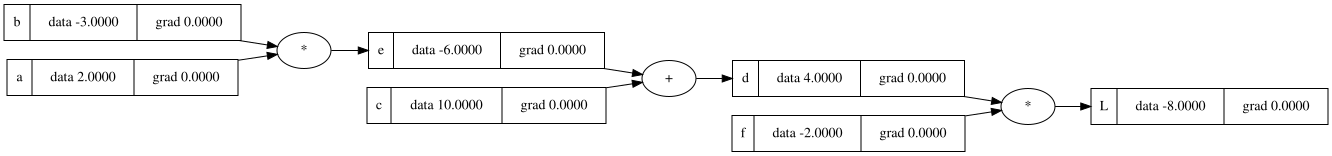

In [117]:
draw_dot(L)

In [118]:
"""
L= d*f
dL/dd=f
dL/df=d
"""
"""
dL/dc
d=c+e
dd/dc=1.0
dd/de=1.0
"""
"""
Chain Rule
dL/dc=(dL/dd)*(dd/dc)=f*1.0=f=-2.0
dL/de=(dL/dd)*(dd/de)=f*1.0=f=-2.0
"""
"""
dL/de=-2.0
e=a*b
de/da=b=-3.0
de/db=a=2.0

Chain Rule
dL/da= (dL/de)*(de/da)=-2.0* -3.0 =6.0
dL/db= (dL/de)*(de/db)=-2.0* 2=-4.0

"""
L.grad=1.0
f.grad=4.0
d.grad=-2.0
c.grad=-2.0
e.grad=-2.0
a.grad=6.0
b.grad=-4.0


We could check grad above by the following lol()

In [119]:
def lol():
    h=0.001
    
    a=Value(2.0,label="a")
    b=Value(-3.0,label="b")
    c=Value(10.0,label="c")
    e=a*b; e.label="e"
    d=e+c; d.label="d"
    f=Value(-2.0, label="f")
    L=d*f; L.label="L"
    L1= L.data
    
    a=Value(2.0,label="a")
    b=Value(-3.0,label="b")
    c=Value(10.0,label="c")
    e=a*b; e.label="e"
    d=e+c; d.label="d"
    f=Value(-2.0, label="f")
    L=d*f; L.label="L"
    L2= L.data
    print ((L2-L1)/h)

In [120]:
lol()

0.0


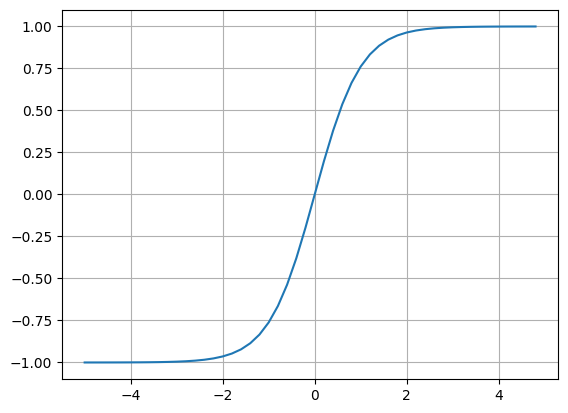

In [121]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid();

In [122]:
# input x1,x2
x1=Value(2.0, label="x1")
x2=Value(0.0, label="x2")
# weight w1,w2
w1=Value(-3.0, label="w1")
w2=Value(1.0, label="w2")
# bias of the neuron
b=Value(6.8813735870195432, label="b")
# x1*w1+x2*w2+b
x1w1= x1*w1; x1w1.label="x1*w1"
x2w2= x2*w2; x2w2.label="x2*w2"
x1w1x2w2=x1*w1+x2*w2; x1w1x2w2.label="x1w1+x2w2"
n= x1w1x2w2+b;n.label="n"
o= n.tanh(); o.label="o"

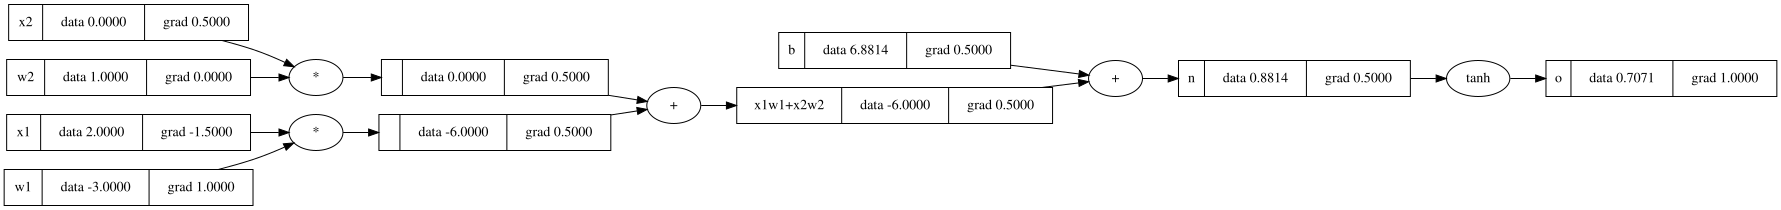

In [131]:
draw_dot(o)

In [130]:
o.backward()

after defind backward function (but without backward())

In [124]:
o.grad=1.0

o._backward()

n._backward()

b._backward()

x1w1x2w2._backward()

x2w2._backward()
x1w1._backward()

Before defined backward function(all by manue)

1-o.data**2

o= tanh(n)
do/dn= 1- o**2

n.grad=0.5

x1w1x2w2.grad=0.5
b.grad=0.5

x1w1.grad=0.5
x2w2.grad=0.5

x2.grad= w2.data*x2w2.grad
w2.grad=x2.data *x2w2.grad

x1.grad= w1.data* x1w1.grad
w1.grad= x1.data* x1w1.grad

#两个a重叠梯度累加
a= Value(-2.0, label="a")
b= a+a; b.label="b"
b.backward()
draw_dot(b)

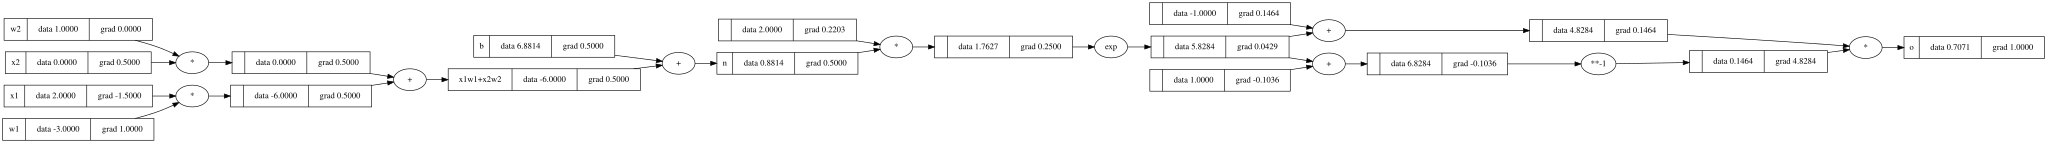

In [22]:
# input x1,x2
x1=Value(2.0, label="x1")
x2=Value(0.0, label="x2")
# weight w1,w2
w1=Value(-3.0, label="w1")
w2=Value(1.0, label="w2")
# bias of the neuron
b=Value(6.8813735870195432, label="b")
# x1*w1+x2*w2+b
x1w1= x1*w1; x1w1.label="x1*w1"
x2w2= x2*w2; x2w2.label="x2*w2"
x1w1x2w2=x1*w1+x2*w2; x1w1x2w2.label="x1w1+x2w2"
n= x1w1x2w2+b;n.label="n"
#-------------
e=(2*n).exp()
o=(e-1)/(e+1)
#-------------
o.label="o"
o.backward()
draw_dot(o)